**Лабораторна робота №1**

“Зменшення розмірності даних”

Лукіна Ольга КН-43


**Мета роботи:** ознайомитися зі зменшенням розмірності даних на прикладі MNIST та застосувати метод головних компонент (PCA) для проєкції даних у простір меншої розмірності.

**Опис даних:** MNIST містить 70 000 зображень рукописних цифр 0–9. Кожне зображення має розмір 28×28 пікселів і подано як вектор із 784 ознак (28·28).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

Завантажуємо набір MNIST та перевіряємо розміри матриці ознак X і вектора міток y. 

In [3]:
X_data, y_labels = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

y_labels = y_labels.astype(int)

print("Розмір матриці ознак:", X_data.shape)
print("Розмір вектора міток:", y_labels.shape)

classes = np.unique(y_labels)
print("Наявні класи:", classes)
print("Кількість класів:", classes.size)

Розмір матриці ознак: (70000, 784)
Розмір вектора міток: (70000,)
Наявні класи: [0 1 2 3 4 5 6 7 8 9]
Кількість класів: 10


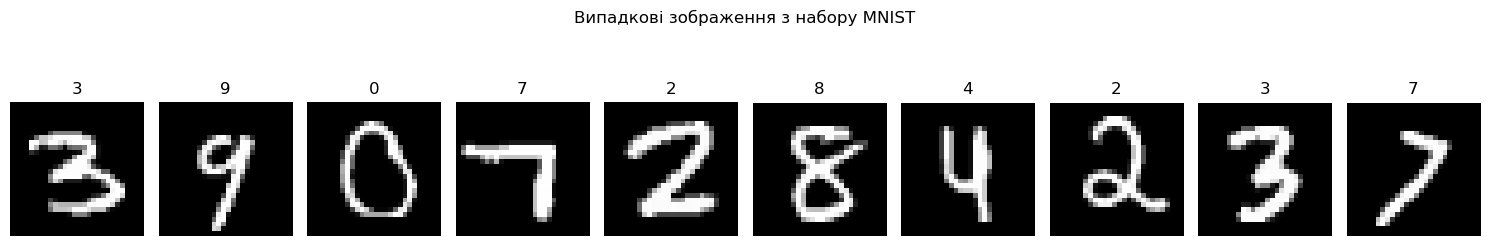

In [5]:
indices = rng.choice(X_data.shape[0], size=10, replace=False)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for ax, idx in zip(axes, indices):
    ax.imshow(X_data[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"{y_labels[idx]}")
    ax.axis("off")

plt.suptitle("Випадкові зображення з набору MNIST", fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
pca_model = PCA(n_components=3, random_state=42)

X_reduced = pca_model.fit_transform(X_data)

print("Розмірність після зменшення:", X_reduced.shape)

Розмірність після зменшення: (70000, 3)


In [7]:
variance_ratio = pca_model.explained_variance_ratio_

print("Частка дисперсії по кожній компоненті:", variance_ratio)
print("Сумарна пояснена дисперсія:", variance_ratio.sum())

Частка дисперсії по кожній компоненті: [0.09746116 0.07155445 0.06149531]
Сумарна пояснена дисперсія: 0.23051091490096481


Отримане значення сумарної поясненої дисперсії показує, яку частину загальної варіативності даних збережено після переходу від 784-вимірного простору до 3-вимірного. Невелике значення означає, що значна частина інформації втрачається, проте така проєкція дозволяє візуалізувати структуру даних.

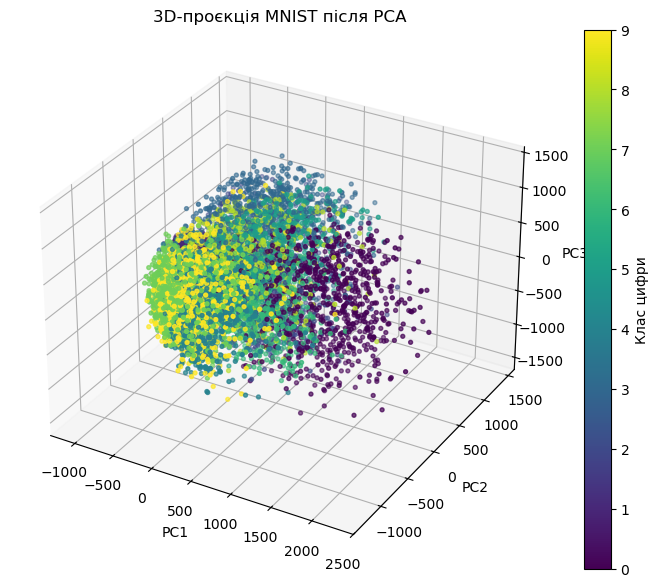

In [10]:
from mpl_toolkits.mplot3d import Axes3D

n_points = 8000
subset_idx = rng.choice(X_reduced.shape[0], size=n_points, replace=False)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_reduced[subset_idx, 0],
    X_reduced[subset_idx, 1],
    X_reduced[subset_idx, 2],
    c=y_labels[subset_idx],
    s=8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

cbar = plt.colorbar(scatter)
cbar.set_label("Клас цифри")

plt.title("3D-проєкція MNIST після PCA")
plt.show()

На 3D-проєкції після PCA бачимо суцільну хмару точок із частковою структуризацією: для окремих цифр можна помітити області підвищеної концентрації, однак чіткого розділення на 10 незалежних кластерів немає.

Після зменшення розмірності відновлюємо наближені зображення у початковому 784-вимірному просторі за допомогою inverse_transform та порівнюємо їх з оригіналами. Це дозволяє якісно оцінити втрати інформації при стисканні до 3 компонент.

In [11]:
X_restored = pca_model.inverse_transform(X_reduced)
print("Розмірність відновлених даних:", X_restored.shape)

Розмірність відновлених даних: (70000, 784)


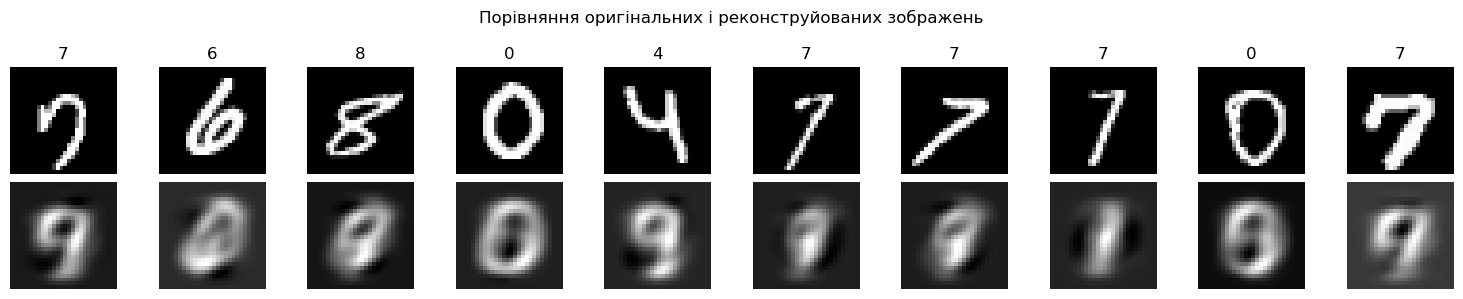

In [12]:
sample_idx = rng.choice(X_data.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for col, i in enumerate(sample_idx):
    axes[0, col].imshow(X_data[i].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(str(y_labels[i]))
    axes[0, col].axis("off")

    axes[1, col].imshow(X_restored[i].reshape(28, 28), cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Оригінал", fontsize=10)
axes[1, 0].set_ylabel("PCA(3)", fontsize=10)

plt.suptitle("Порівняння оригінальних і реконструйованих зображень", fontsize=12)
plt.tight_layout()
plt.show()

Реконструкція зображень після стискання до трьох головних компонент демонструє суттєву втрату деталей. Це пояснюється тим, що тривимірне представлення не здатне повністю описати складну структуру 784-вимірного простору пікселів. Таким чином, PCA(3) забезпечує сильне зменшення розмірності ціною значної втрати інформації.

Для різних значень кількості головних компонент k обчислюємо середньоквадратичну похибку реконструкції (MSE) та частку поясненої дисперсії. Це дозволить оцінити компроміс між зменшенням розмірності та втратою інформації.

In [15]:
subset_size = 12000
subset_indices = rng.choice(X_data.shape[0], size=subset_size, replace=False)

X_subset = X_data[subset_indices]

k_values = [1, 2, 3, 5, 10, 20, 30, 50, 80, 100, 150, 200]

mse_values = []
explained_values = []

for k in k_values:
    pca_temp = PCA(n_components=k, random_state=42)
    Z = pca_temp.fit_transform(X_subset)
    X_back = pca_temp.inverse_transform(Z)

    mse = np.mean((X_subset - X_back) ** 2)

    mse_values.append(mse)
    explained_values.append(pca_temp.explained_variance_ratio_.sum())

for k, mse, ev in zip(k_values, mse_values, explained_values):
    print(f"k={k:3d}  MSE={mse:.2f}  Explained variance={ev:.4f}")

k=  1  MSE=3958.05  Explained variance=0.0957
k=  2  MSE=3646.04  Explained variance=0.1670
k=  3  MSE=3376.46  Explained variance=0.2286
k=  5  MSE=2927.46  Explained variance=0.3312
k= 10  MSE=2245.36  Explained variance=0.4870
k= 20  MSE=1556.48  Explained variance=0.6444
k= 30  MSE=1172.87  Explained variance=0.7320
k= 50  MSE=760.78  Explained variance=0.8262
k= 80  MSE=473.53  Explained variance=0.8918
k=100  MSE=368.78  Explained variance=0.9157
k=150  MSE=222.05  Explained variance=0.9493
k=200  MSE=143.39  Explained variance=0.9672


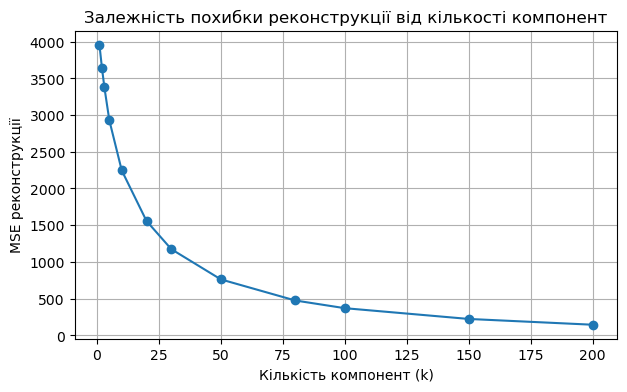

In [16]:
plt.figure(figsize=(7,4))
plt.plot(k_values, mse_values, marker='o')
plt.xlabel("Кількість компонент (k)")
plt.ylabel("MSE реконструкції")
plt.title("Залежність похибки реконструкції від кількості компонент")
plt.grid(True)
plt.show()

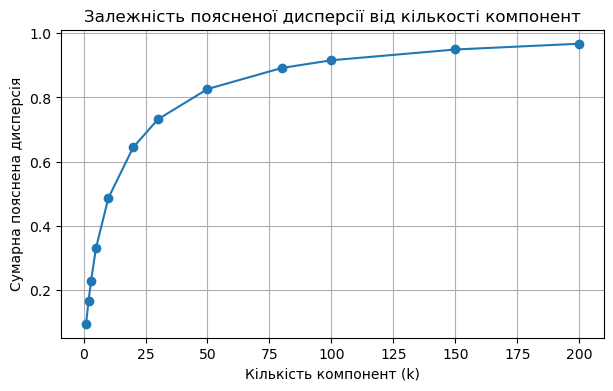

In [17]:
plt.figure(figsize=(7,4))
plt.plot(k_values, explained_values, marker='o')
plt.xlabel("Кількість компонент (k)")
plt.ylabel("Сумарна пояснена дисперсія")
plt.title("Залежність поясненої дисперсії від кількості компонент")
plt.grid(True)
plt.show()

Зі збільшенням k похибка реконструкції зменшується, а пояснена дисперсія зростає. Найбільш різке покращення спостерігається при малих значеннях k (до 30–50), після чого приріст стає повільнішим. При k=200 зберігається близько 97% дисперсії, що свідчить про ефективність зменшення розмірності.

**Висновок**

У роботі було застосовано метод головних компонент для зменшення розмірності зображень набору MNIST з 784 до меншої кількості ознак. Проєкція у тривимірний простір дозволила візуалізувати структуру даних, проте повного розділення класів не спостерігається через лінійний характер PCA та схожість написання цифр.

Реконструкція з 3 компонент показала значну втрату деталей, що підтверджує недостатність малої кількості компонент для точного відновлення зображень. Аналіз залежності MSE від k продемонстрував, що зі збільшенням кількості компонент якість реконструкції покращується, а при k=200 зберігається близько 97% дисперсії даних.

Отже, PCA дозволяє суттєво зменшити розмірність простору ознак із відносно невеликою втратою інформації, забезпечуючи баланс між компактністю представлення та точністю відновлення.